# Dependencies

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import random_split, DataLoader
import numpy as np

# Set Random Seed

In [ ]:
import numpy as np
import random

# Set seed
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Ensures deterministic behavior

set_seed(42)

# Find Device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters

In [ ]:
batch_size = 128 # batch size
num_epochs = 30 # number of epochs
learning_rate = 0.001 # learning rate
l1_lambda = 1e-5 # lambda for L1 regularization

# Prepare Dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                             download=True, transform=transform)

val_size = 10000 # Corresponds to 20% of training set
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


# Model: ResNet18

In [ ]:
class ResNet18_CIFAR10(nn.Module):
    def __init__(self):
        super(ResNet18_CIFAR10, self).__init__()
        self.model = torchvision.models.resnet18(pretrained=False, num_classes=10)
        # Updating so that compatible with image sizes
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()

    def forward(self, x):
        return self.model(x)

model = ResNet18_CIFAR10().to(device)

# Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss() # Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # ADAM Optimizer

# L1 Penalty

In [ ]:
def compute_l1_penalty(model, l1_lambda):
    l1_norm = 0.0
    for param in model.parameters():
        l1_norm += torch.sum(torch.abs(param))
    return l1_lambda * l1_norm

# Training with Validation for Baseline

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Add L1 penalty
        l1_penalty = compute_l1_penalty(model, l1_lambda)
        total_loss = loss + l1_penalty

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_losses.append(running_loss / total)
    train_accuracies.append(correct / total)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_accuracies[-1]*100:.2f}%  Val Acc: {val_accuracies[-1]*100:.2f}%")

# Train Accuracy

In [ ]:
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()

print(f"\nTrain Accuracy: {100 * test_correct / test_total:.2f}%")


Train Accuracy: 98.29%


# Test Accuracy

In [ ]:
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()

print(f"\nTest Accuracy: {100 * test_correct / test_total:.2f}%")


Test Accuracy: 82.52%


# Plots

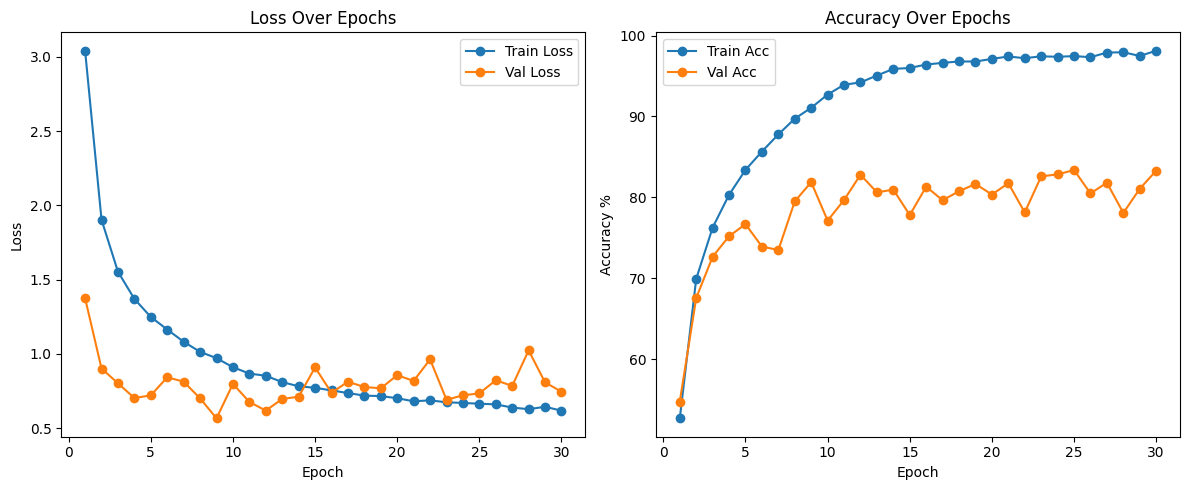

In [ ]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [100*acc for acc in train_accuracies], label='Train Acc', marker='o')
plt.plot(epochs, [100*acc for acc in val_accuracies], label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

# With Pruning

In [ ]:
import torch.nn.utils.prune as prune

## Hyperparameters

In [ ]:
batch_size = 128
num_epochs = 30
learning_rate = 0.001
l1_lambda = 1e-5

# Extra hyperparameters needed for pruning
prune_interval = 1
percentile = 90

## Pruning method

In [ ]:
def structured_filter_prune(model, percentile):
    total_filters = 0
    pruned_filters = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            weight = module.weight.data
            grad = module.weight.grad

            if grad is None:
                continue

            # Compute mean weight and grad for each filter (output channel)
            mean_weight = weight.view(weight.size(0), -1).abs().mean(dim=1)
            mean_grad = grad.view(grad.size(0), -1).abs().mean(dim=1)

            weight_thresh = torch.quantile(mean_weight, percentile / 100)
            grad_thresh = torch.quantile(mean_grad, percentile / 100)

            # Determine filters to prune
            prune_mask = (mean_weight < weight_thresh) & (mean_grad < grad_thresh)

            for idx, should_prune in enumerate(prune_mask):
                if should_prune:
                    weight[idx] = 0  # Soft pruning by zeroing out filter
                    pruned_filters += 1

            total_filters += weight.size(0)

    return pruned_filters, total_filters

## Sparsity Function

In [ ]:
def calculate_weight_sparsity(model):
    total_weights = 0
    zero_weights = 0
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            weight = module.weight.data
            total_weights += weight.numel()
            zero_weights += (weight == 0).sum().item()
    return 100 * zero_weights / total_weights

# Training with Validation and Pruning

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Add L1 penalty
        l1_penalty = compute_l1_penalty(model, l1_lambda)
        total_loss = loss + l1_penalty

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_losses.append(running_loss / total)
    train_accuracies.append(correct / total)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_accuracies[-1]*100:.2f}%  Val Acc: {val_accuracies[-1]*100:.2f}%")

    # Apply pruning
    if (epoch + 1) % prune_interval == 0:
        pruned, total = structured_filter_prune(model, percentile)
        print(f"Pruned {pruned}/{total} filters ({100 * pruned / total:.2f}%) at epoch {epoch+1}")

Epoch [1/30] Train Acc: 53.28%  Val Acc: 60.84%
Pruned 3982/4800 filters (82.96%) at epoch 1
Epoch [2/30] Train Acc: 37.51%  Val Acc: 40.68%
Pruned 3867/4800 filters (80.56%) at epoch 2
Epoch [3/30] Train Acc: 36.09%  Val Acc: 39.37%
Pruned 3841/4800 filters (80.02%) at epoch 3
Epoch [4/30] Train Acc: 36.70%  Val Acc: 41.54%
Pruned 3852/4800 filters (80.25%) at epoch 4
Epoch [5/30] Train Acc: 38.94%  Val Acc: 46.43%
Pruned 3831/4800 filters (79.81%) at epoch 5
Epoch [6/30] Train Acc: 42.50%  Val Acc: 45.08%
Pruned 3838/4800 filters (79.96%) at epoch 6
Epoch [7/30] Train Acc: 38.38%  Val Acc: 48.56%
Pruned 3846/4800 filters (80.12%) at epoch 7
Epoch [8/30] Train Acc: 39.37%  Val Acc: 44.30%
Pruned 3841/4800 filters (80.02%) at epoch 8
Epoch [9/30] Train Acc: 42.02%  Val Acc: 45.77%
Pruned 3838/4800 filters (79.96%) at epoch 9
Epoch [10/30] Train Acc: 44.66%  Val Acc: 46.91%
Pruned 3838/4800 filters (79.96%) at epoch 10
Epoch [11/30] Train Acc: 44.38%  Val Acc: 49.60%
Pruned 3831/4800 fi

In [ ]:
sparsity = calculate_weight_sparsity(model)
print(f"Final convolutional weight sparsity: {sparsity:.2f}%")

Final convolutional weight sparsity: 80.69%


## Train Accuracy

In [ ]:
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()

print(f"\nTrain Accuracy: {100 * test_correct / test_total:.2f}%")


Train Accuracy: 10.19%


## Test Accuracy

In [ ]:
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()

print(f"\nTest Accuracy: {100 * test_correct / test_total:.2f}%")


Test Accuracy: 10.15%


## Plots

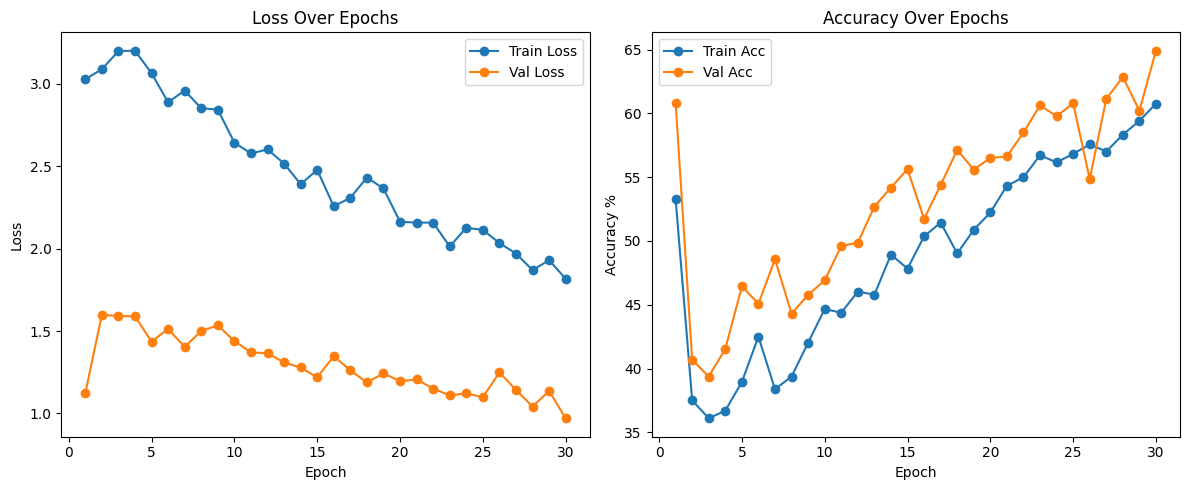

In [ ]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [100*acc for acc in train_accuracies], label='Train Acc', marker='o')
plt.plot(epochs, [100*acc for acc in val_accuracies], label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()